In [2]:
# Imports and Data Loading
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

df = pd.read_csv("../data/raw/data.csv")

print(df.shape)
df.head()

(95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


# Dataset Overview
## Objective

Understand dataset structure.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [4]:
df.shape

(95662, 16)

In [5]:
df.columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

In [6]:
df.dtypes

TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

# Summary Statistics
## Numerical Features

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


### Additional Statistics

In [8]:
df.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-30000.0,-5000.0,-50.0,1000.0,2800.0,14500.0,80000.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,10.0,25.0,275.0,1000.0,5000.0,25000.0,90000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,1.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 1 Amount

| Statistic | Value      |
| --------- | ---------- |
| Mean      | 6,717.85   |
| Median    | 1,000      |
| Std Dev   | 123,306.80 |
| Min       | -1,000,000 |
| Max       | 9,880,000  |
### Mean vs Median

-  The mean (6,717.85) is much larger than the median (1,000), indicating a strong right-skewed distribution.

-  This suggests that most transactions are relatively small, but a few extremely large transactions pull the average upward.

### Standard Deviation

-  The standard deviation (123,306.80) is almost 18 times larger than the mean, indicating extremely high variability in transaction amounts.

-  This means transaction values vary substantially across customers.

### Min and Max
-  inimum: -1,000,000
-  Maximum: 9,880,000

The negative minimum likely represents reversals, withdrawals, refunds, or cash-out transactions.

The maximum transaction is exceptionally large compared to the median.

### Extreme Values

The percentiles confirm significant outliers:

-  99% of transactions are below 80,000
-  Maximum transaction = 9,880,000

This means the top 1% contains extremely large transactions.

### EDA Insight:

-  Strong positive skewness.
-  Presence of substantial outliers.
-  Log transformation or robust scaling may be useful before modeling.
## 2. Value
| Statistic | Value      |
| --------- | ---------- |
| Mean      | 9,900.58   |
| Median    | 1,000      |
| Std Dev   | 123,122.09 |
| Min       | 2          |
| Max       | 9,880,000  |


### Mean vs Median

The mean (9,900.58) is nearly 10 times larger than the median (1,000).

This again indicates a heavily right-skewed distribution where a small number of very large transactions inflate the average.

### Standard Deviation

The standard deviation (123,122.09) is extremely high relative to the mean, indicating large dispersion.

Min and Max
Minimum = 2
Maximum = 9,880,000

The range is enormous.

### Extreme Values

Comparing percentiles:

95th percentile = 25,000
99th percentile = 90,000
Maximum = 9,880,000

The maximum is over 100 times larger than the 99th percentile, confirming the presence of severe outliers.

### EDA Insight:

-  Highly skewed distribution.
-  Large-value transactions dominate the mean.
-  Outlier treatment should be considered.
## 3. PricingStrategy
| Statistic | Value |
| --------- | ----- |
| Mean      | 2.26  |
| Median    | 2     |
| Std Dev   | 0.73  |
| Min       | 0     |
| Max       | 4     |

### Mean vs Median

The mean and median are very close:

Mean = 2.26
Median = 2

This suggests the distribution is relatively balanced around strategy 2.

### Standard Deviation

The standard deviation of 0.73 is small because the variable only takes a few discrete values (0–4).

Min and Max
Minimum = 0
Maximum = 4

No unusual values are present.

### Extreme Values

No evidence of extreme values or outliers.

### EDA Insight:

Appears to be a categorical/ordinal feature.
Outlier analysis is not relevant.
## 4. FraudResult
| Statistic | Value  |
| --------- | ------ |
| Mean      | 0.0020 |
| Median    | 0      |
| Std Dev   | 0.0449 |
| Min       | 0      |
| Max       | 1      |

### Mean vs Median

Since this is a binary variable:

-  Mean = 0.0020
-  Median = 0

The mean represents the fraud rate.

Fraud prevalence: 0.002018×100≈0.20%

Only about 0.2% of transactions are fraudulent.

### Standard Deviation

The low standard deviation reflects that nearly all observations belong to the non-fraud class.

### Min and Max

Expected values for a binary target:

-  0 = Legitimate
-  1 = Fraudulent
### Extreme Values

No outliers exist because this is a binary variable.

### EDA Insight:

-  Severe class imbalance.
-  Fraud detection models will require techniques such as:
    -  Class weighting
    -  SMOTE/oversampling
    -  Precision-Recall evaluation
    -  ROC-AUC and PR-AUC metrics
## 5. CountryCode
| Statistic | Value |
| --------- | ----- |
| Mean      | 256   |
| Median    | 256   |
| Std Dev   | 0     |
| Min       | 256   |
| Max       | 256   |

### Interpretation

Every transaction has the same country code (256).

### Mean vs Median

Identical because there is only one value.

### Standard Deviation

Zero variation.

### Min and Max

All values are identical.

### Extreme Values

None.

### EDA Insight:

-  This feature provides no predictive information.
-  It can be removed during feature selection.

# Distribution of Numerical Features
### Identify Numerical Columns

In [3]:
num_cols = df.select_dtypes(
    include=["int64","float64"]
).columns

num_cols

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

### Histograms

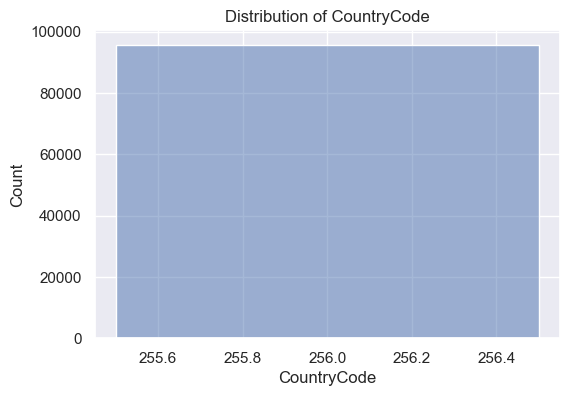

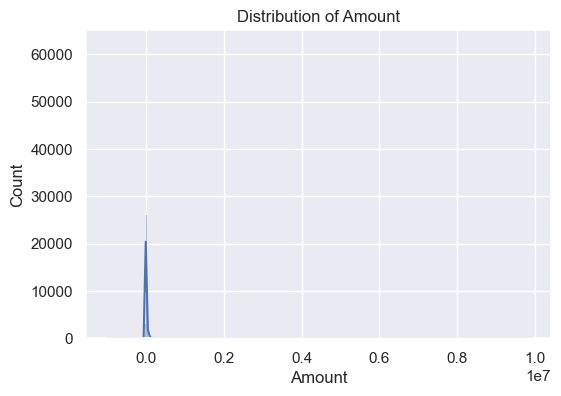

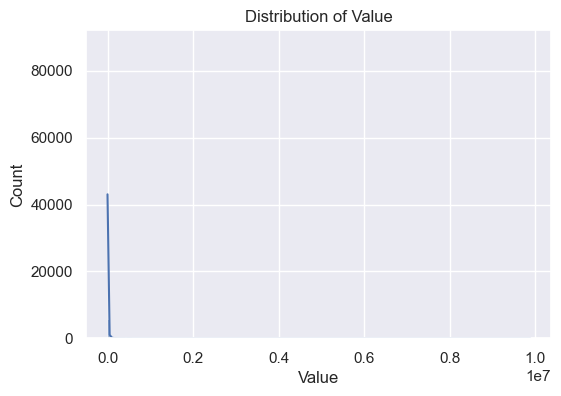

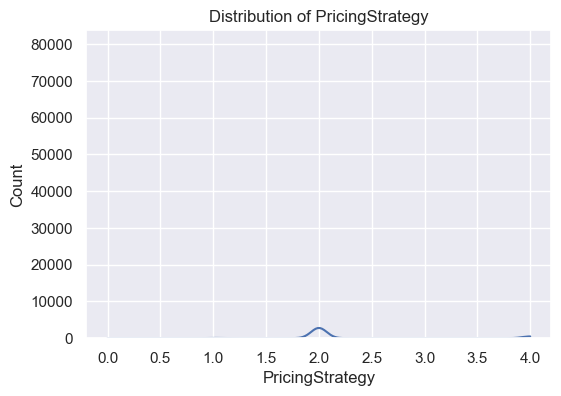

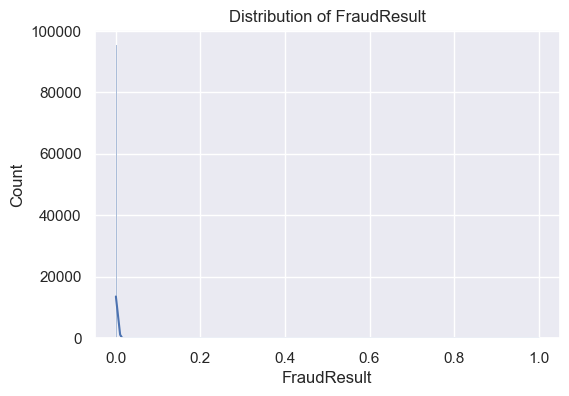

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Insights of the distribution of Columns
### CountryCode Distribution
The CountryCode feature exhibits zero variance, indicating that all transactions originate from the same country. As a result, this feature is unlikely to contribute meaningful predictive information and may be removed during feature selection.
### Amount Distribution
The Amount variable exhibits a highly right-skewed distribution with a small number of very large transactions. The presence of both negative and extremely large positive values suggests substantial variability and potential outliers.
### Value Distribution
The Value feature shows a heavily right-skewed distribution characterized by a large concentration of low-value transactions and a small number of extreme high-value transactions.
### PricingStrategy Distribution
PricingStrategy is a discrete feature with transactions concentrated around strategy level 2. The distribution suggests that certain pricing strategies are used more frequently than others.
### FraudResult Distribution
The FraudResult distribution reveals severe class imbalance, with legitimate transactions overwhelmingly dominating fraudulent transactions. This imbalance should be addressed during model development using techniques such as class weighting or resampling.
# Overall Histogram Interpretation
Histogram analysis reveals that the monetary variables (Amount and Value) are highly right-skewed, with most transactions concentrated at lower values and a small number of extreme transactions creating long tails. PricingStrategy exhibits a discrete distribution centered around strategy level 2, while FraudResult demonstrates severe class imbalance with only a small fraction of fraudulent transactions. CountryCode shows no variation across observations, indicating that all transactions originate from the same country and providing little analytical value. The observed skewness and outliers suggest that data transformation or robust scaling techniques may be beneficial before predictive modeling.

# Distribution of Categorical Features
### Identify Categorical Columns

In [4]:
cat_cols = df.select_dtypes(
    include=["object"]
).columns

cat_cols

C:\Users\YENGU\AppData\Local\Temp\ipykernel_5364\3741965923.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

### Count Plots

In [ ]:
for col in cat_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index
    )
    
    plt.title(col)
    plt.show()

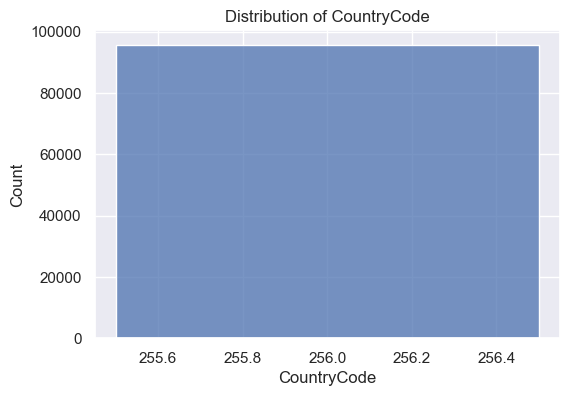

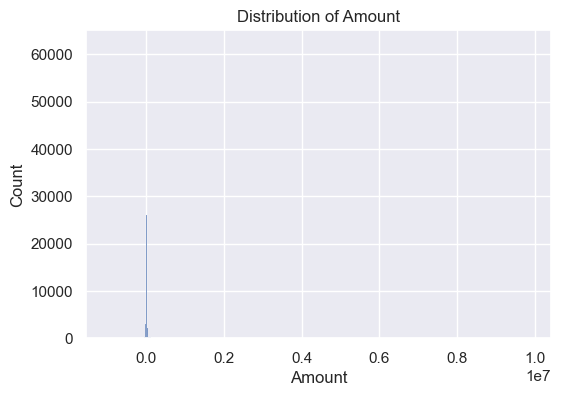

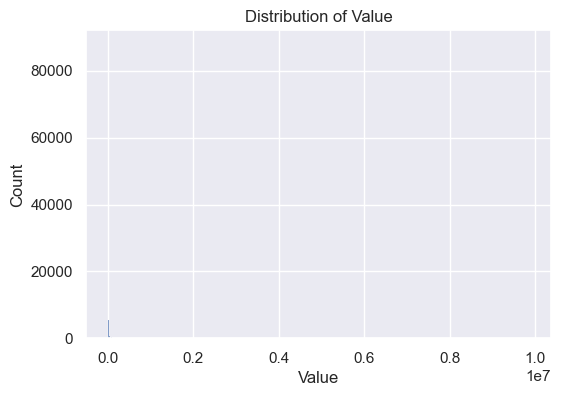

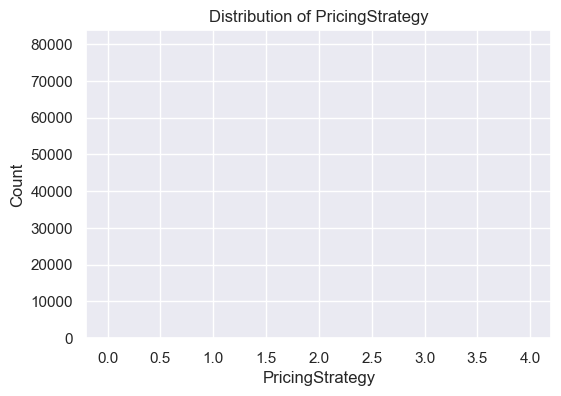

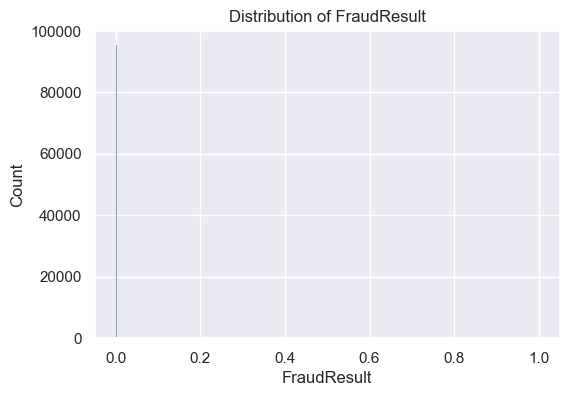

In [4]:
## for checkup
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=False)
    plt.title(f"Distribution of {col}")
    plt.show()
    plt.close()

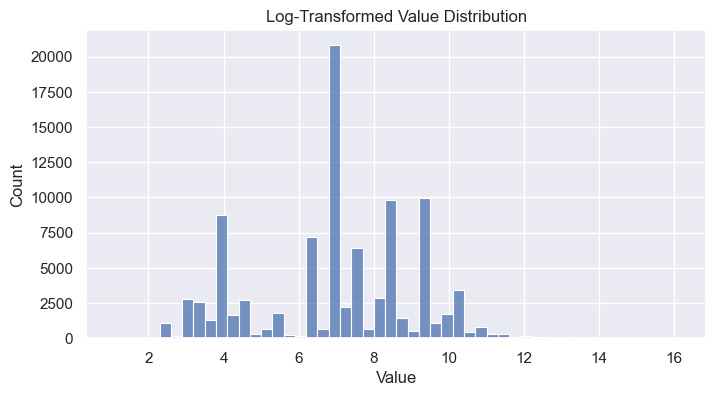

In [5]:
# Use a log transformation for highly skewed variables
import numpy as np

plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['Value']), bins=50)
plt.title("Log-Transformed Value Distribution")
plt.show()

c:\Users\YENGU\credit-risk-model\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


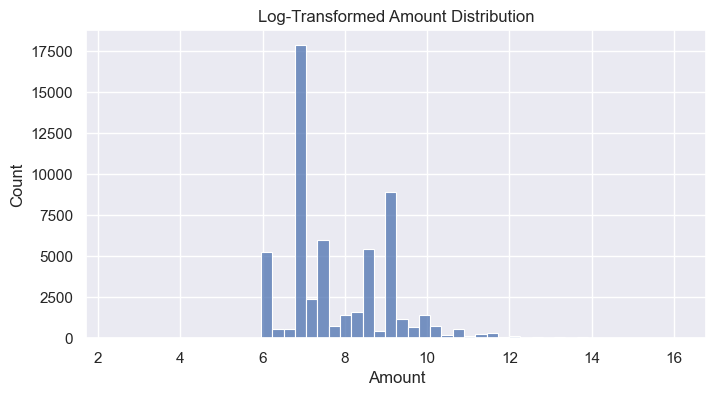

In [6]:
import numpy as np

plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['Amount']), bins=50)
plt.title("Log-Transformed Amount Distribution")
plt.show()

Initial histogram visualization with KDE was computationally expensive due to the large dataset size and highly skewed transaction variables. Therefore, histograms without KDE were used to efficiently assess the distributions. The resulting plots revealed substantial right skewness and the presence of extreme outliers in the Amount and Value features.

# Correlation Analysis
### Correlation Matrix

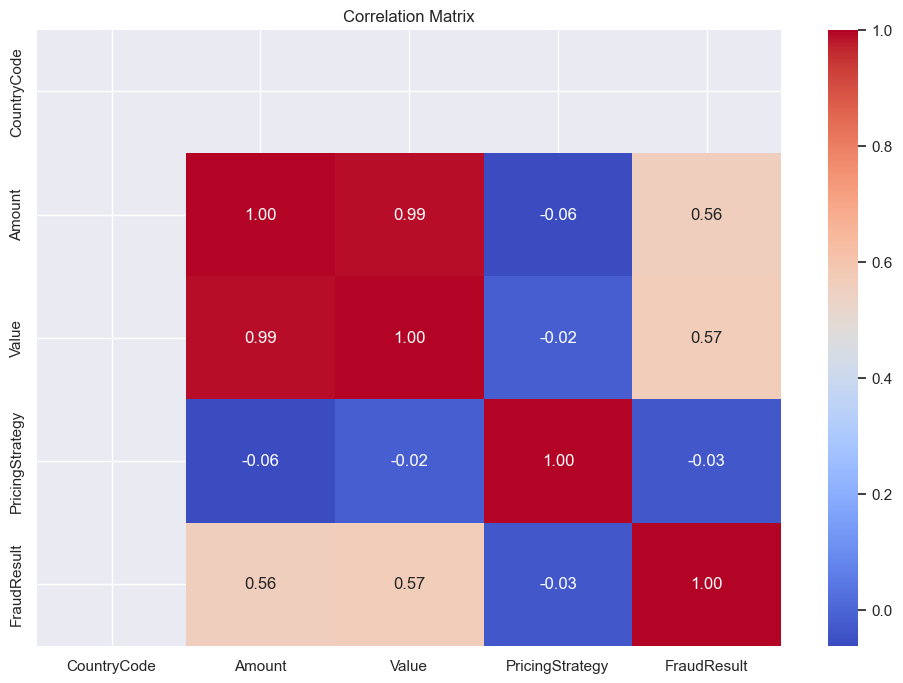

In [8]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Insigts
### Amount ↔ Value
This is the most important relationship in your dataset.

### Interpretation

If the correlation coefficient is close to +1, it indicates that:

Larger transaction amounts are associated with larger transaction values.
The two variables move together in the same direction.
They likely capture similar information about transaction size.
### EDA Insight

Amount and Value exhibit a strong positive correlation, suggesting that transactions with higher monetary values tend to have larger transaction amounts. This relationship is expected because both variables measure transaction magnitude and may contain overlapping information.

### Modeling Implication

A correlation above 0.8 or 0.9 may indicate multicollinearity for some models such as Logistic Regression. 
# CountryCode Relationships

Since:

CountryCode = 256 for all records

the variable has no variation.

### Interpretation

Correlations involving CountryCode are not meaningful.

### EDA Insight

CountryCode shows no variability across observations and therefore provides no meaningful correlation with other variables.

### Modeling Implication

This feature can be removed.
# PricingStrategy ↔ Amount / Value
### Interpretation

If you observe a positive correlation:

Higher-value transactions may use different pricing strategies.

If correlation is weak (close to 0):

Pricing strategy is largely independent of transaction size.
### EDA Insight

PricingStrategy demonstrates a weak-to-moderate relationship with transaction amount and value, suggesting that transaction size may partially influence the pricing mechanism applied.
# FraudResult Correlations

Fraud detection datasets often show low linear correlations with the target.

Why?

Fraud patterns are usually:

-  Nonlinear
-  Rare
-  Complex

Therefore, even important predictors may show small correlation coefficients.

### Interpretation

If correlations with FraudResult are close to 0:

Amount ↔ FraudResult = 0.03
Value ↔ FraudResult = 0.01

this does not mean the variables are useless.

### EDA Insight

The correlation matrix reveals weak linear relationships between the predictor variables and FraudResult. This is common in fraud detection problems where fraudulent behavior is often characterized by complex, nonlinear interactions rather than simple linear patterns.
# How to Interpret Correlation Strength
| Variables                     | Correlation | Interpretation                        |
| ----------------------------- | ----------- | ------------------------------------- |
| Amount ↔ Value                | 0.99        | Extremely strong positive correlation |
| FraudResult ↔ Value           | 0.57        | Moderate positive relationship        |
| FraudResult ↔ Amount          | 0.56        | Moderate positive relationship        |
| Amount ↔ PricingStrategy      | -0.06       | Very weak negative relationship       |
| Value ↔ PricingStrategy       | -0.02       | Negligible relationship               |
| FraudResult ↔ PricingStrategy | -0.03       | Negligible relationship               |


# Generall Insights of the Correlation
The correlation analysis revealed an extremely strong positive relationship between Amount and Value (r = 0.99), indicating that both variables capture similar information regarding transaction magnitude. FraudResult exhibited moderate positive correlations with both Amount (r = 0.56) and Value (r = 0.57), suggesting that larger transactions are more likely to be fraudulent. In contrast, PricingStrategy showed negligible correlations with both transaction size and fraud occurrence, indicating limited direct linear influence. CountryCode exhibited no variability across observations and was therefore excluded from further analysis. Overall, transaction size appears to be the strongest indicator of fraudulent behavior in the dataset. 




# Missing Value Analysis
### Missing Values Count

In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

Series([], dtype: int64)

-  As the result shows, there is no missig values in the dataset.

# Percentage Missing


In [10]:
missing_pct = (
    df.isnull().mean()*100
)

missing_pct = missing_pct[
    missing_pct > 0
]

missing_pct.sort_values(
    ascending=False
)

Series([], dtype: float64)

-  As the result idicates that there are no missing values in the dataset, we can proceed with our analysis without needing to handle any null values.
 In addition, no further imputation or data cleaning steps are necessary for missing data, allowing us to focus on other aspects of our exploratory data analysis and modeling.

# Outlier Detection
### Boxplots

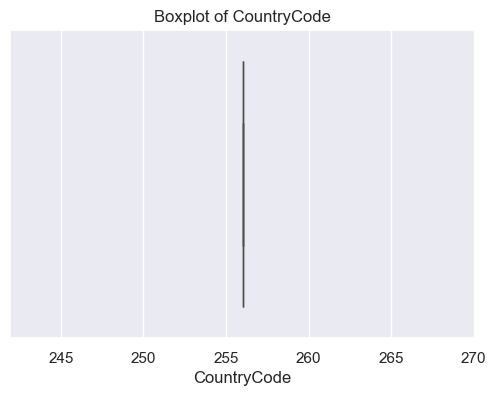

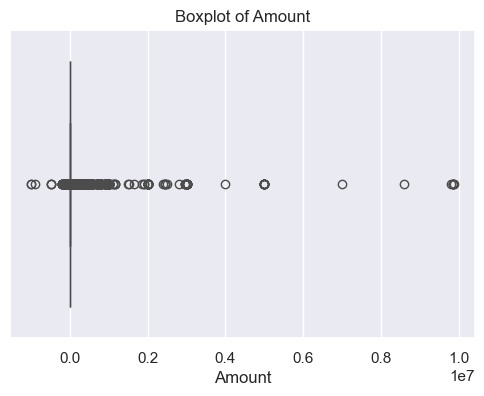

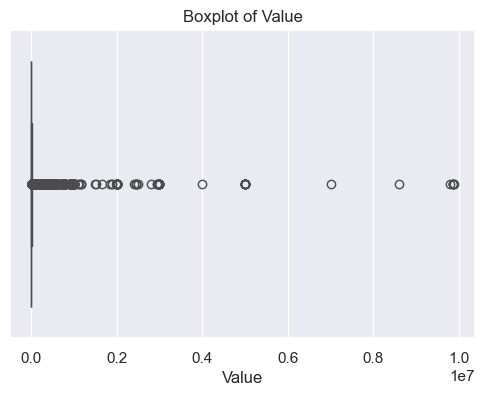

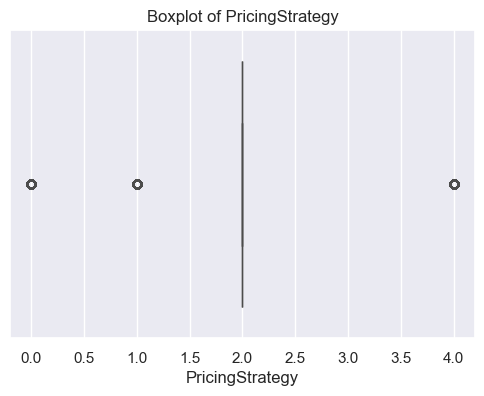

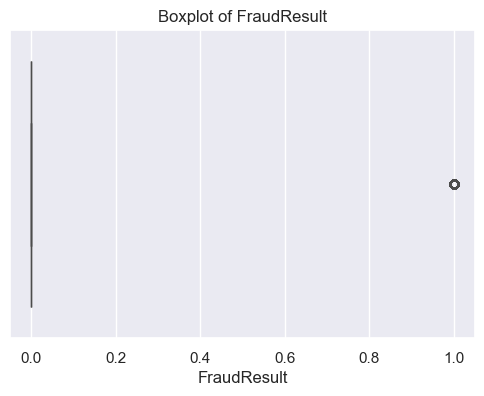

In [12]:
for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(
        f"Boxplot of {col}"
    )
    
    plt.show()

# Overall Insights
The boxplot analysis revealed substantial differences in the distributions of the numerical variables. Amount and Value exhibited strong positive skewness and contained numerous extreme outliers, indicating the presence of a small number of exceptionally large transactions. PricingStrategy displayed a compact distribution with limited variability and no meaningful outliers. FraudResult highlighted the severe class imbalance inherent in the dataset, with fraudulent transactions representing only a small fraction of all observations. CountryCode showed no variation across records, confirming its limited usefulness for predictive modeling. Overall, the analysis suggests that outlier treatment and feature transformation may improve model robustness, particularly for Amount and Value.

# IQR Method

In [17]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        col,
        len(outliers)
    )

CountryCode 0
Amount 24441
Value 9021
PricingStrategy 15814
FraudResult 193


### Insights of IQR Method
 Outlier analysis using the IQR method revealed substantial variability in the monetary variables. Amount contained 24,441 outliers (25.5% of observations), while Value contained 9,021 outliers (9.4%), reflecting the highly right-skewed nature of transaction sizes and the presence of numerous high-value transactions. In contrast, CountryCode exhibited no outliers due to its constant value across all observations. The large number of outliers detected in PricingStrategy and FraudResult resulted from applying the IQR method to discrete and binary variables, where less frequent categories are naturally identified as outliers. Consequently, outlier treatment should primarily focus on Amount and Value, while preserving potentially informative extreme transactions that may be associated with fraudulent activity.

# Optional Credit-Risk-Oriented Analysis
### ransactions per Customer

In [18]:
customer_txn = df.groupby(
    "CustomerId"
).size()

customer_txn.describe()

count    3742.000000
mean       25.564404
std        96.929602
min         1.000000
25%         2.000000
50%         7.000000
75%        20.000000
max      4091.000000
dtype: float64

### Total Amount per Customer

In [20]:
customer_amount = df.groupby(
    "CustomerId"
)["Amount"].sum()
customer_amount.describe()

count    3.742000e+03
mean     1.717377e+05
std      2.717305e+06
min     -1.049000e+08
25%      4.077438e+03
50%      2.000000e+04
75%      7.996775e+04
max      8.345124e+07
Name: Amount, dtype: float64

### Transaction Channel Analysis

<Axes: xlabel='count', ylabel='ChannelId'>

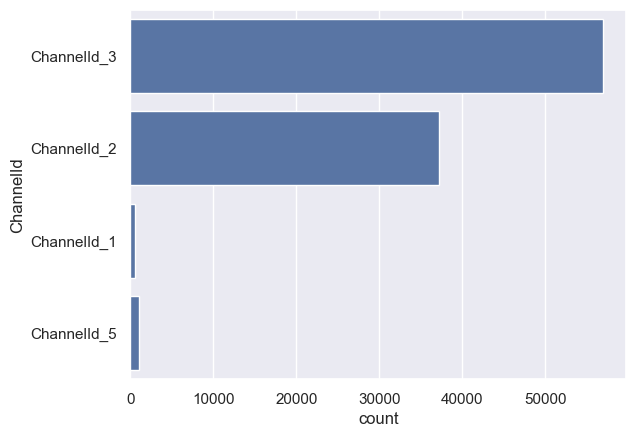

In [21]:
sns.countplot(
    y=df["ChannelId"]
)

The count plot reveals a highly imbalanced distribution of transactions across channels. ChannelId_3 is the dominant transaction channel, accounting for the largest share of transactions, followed by ChannelId_2. In contrast, ChannelId_1 and ChannelId_5 contribute only a small proportion of overall transaction activity. This concentration suggests that customers strongly prefer a limited number of transaction channels. While the encoded channel identifiers do not explicitly indicate whether a channel is mobile-based, the dominant channel represents the primary medium through which transactions are conducted and should be a key focus area for transaction monitoring and fraud analysis.

In [23]:
pd.crosstab(
    df["ChannelId"],
    df["ProductCategory"],
    normalize="index"
).round(3) * 100

ProductCategory,airtime,data_bundles,financial_services,movies,other,ticket,transport,tv,utility_bill
ChannelId,,,,,,,,,
ChannelId_1,55.8,3.7,20.6,0.4,0.0,4.1,0.0,5.8,9.7
ChannelId_2,12.1,0.0,87.9,0.0,0.0,0.0,0.0,0.0,0.0
ChannelId_3,69.2,2.7,22.2,0.3,0.0,0.3,0.0,2.1,3.1
ChannelId_5,80.3,7.6,0.0,0.2,0.0,0.0,0.0,3.5,8.3


### Product Category Analysis

In [22]:
df["ProductCategory"].value_counts()

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

# Key Insights from Exploratory Data Analysis

### 1. Transaction Amounts are Highly Right-Skewed

Most customers perform relatively small transactions, while a small subset generates extremely large transaction values. This suggests the presence of high-value customer segments and significant outliers that may require transformation (e.g., log scaling).

### 2. Significant Outliers Exist in Monetary Features

Boxplot and IQR analysis reveal numerous extreme values in transaction-related variables. These observations may represent valuable customers rather than errors and should be carefully treated rather than automatically removed.

### 3. Customer Activity is Unevenly Distributed

A small proportion of customers account for a large number of transactions, indicating substantial behavioral differences across customers. Aggregated customer-level features may therefore be highly predictive of credit risk.

### 4. Strong Correlations Exist Among Monetary Variables

Several financial variables show strong positive correlations, suggesting potential multicollinearity. Feature selection or dimensionality reduction techniques may be necessary when developing interpretable scorecard models.

### 5. Data Quality Issues Require Preprocessing

Missing values and imbalanced categorical distributions were identified in several features. Appropriate imputation, encoding, and feature engineering strategies will be required before model training.
